# Weather Trend Forecasting

## PM Accelerator Mission

The Product Manager Accelerator Program is designed to support PM professionals through every stage of their careers. From students looking for entry-level jobs to Directors looking to take on a leadership role, this program has helped over hundreds of students fulfill their career aspirations.

## Data Cleaning & Preproccessing

In [1]:
import pandas as pd

df = pd.read_csv("GlobalWeatherRepository.csv")

df.describe()

,latitude,longitude,last_updated_epoch,temperature_celsius,temperature_fahrenheit,wind_mph,wind_kph,wind_degree,pressure_mb,pressure_in,...,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,moon_illumination
count,131173.000000,131173.000000,1.311730e+05,131173.000000,131173.000000,131173.000000,131173.000000,131173.000000,131173.000000,131173.00000,...,131173.000000,131173.000000,131173.000000,131173.000000,131173.000000,131173.000000,131173.000000,131173.000000,131173.000000,131173.000000
mean,19.204695,21.972621,1.745038e+09,21.369180,70.466307,8.034313,12.933588,168.836925,1014.092153,29.94551,...,18.281722,467.226452,58.353717,15.114514,10.493555,24.404038,48.818016,1.705305,2.620532,49.337554
std,24.419535,65.788131,1.684234e+07,9.696369,17.453314,7.277684,11.709151,103.607761,10.463831,0.30896,...,13.892850,767.196950,30.925283,23.924301,36.167221,37.274879,150.548947,0.944977,2.456944,35.108550
min,-41.300000,-175.200000,1.715849e+09,-29.800000,-21.600000,2.200000,3.600000,1.000000,947.000000,27.96000,...,3.600000,-9999.000000,0.000000,0.000000,-9999.000000,0.168000,-1848.150000,1.000000,1.000000,0.000000
25%,3.870000,-6.836100,1.730538e+09,16.100000,61.000000,3.800000,6.100000,80.000000,1010.000000,29.83000,...,10.300000,206.850000,38.000000,1.665000,1.100000,7.150000,10.000000,1.000000,1.000000,15.000000
50%,17.250000,23.236100,1.745053e+09,24.000000,75.200000,6.700000,10.800000,161.000000,1014.000000,29.93000,...,15.400000,297.850000,55.000000,5.550000,2.405000,14.245000,20.165000,1.000000,2.000000,49.000000
75%,40.400000,50.580000,1.759559e+09,28.000000,82.400000,11.000000,17.600000,255.000000,1018.000000,30.06000,...,24.200000,466.200000,74.000000,17.575000,8.500000,27.935000,41.810000,2.000000,3.000000,84.000000
max,64.150000,179.220000,1.774248e+09,49.200000,120.600000,1841.200000,2963.200000,360.000000,3006.000000,88.77000,...,2970.400000,38879.398000,480.700000,427.700000,521.330000,1614.100000,6037.290000,6.000000,10.000000,100.000000


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 131173 entries, 0 to 131172
Data columns (total 41 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   country                       131173 non-null  object 
 1   location_name                 131173 non-null  object 
 2   latitude                      131173 non-null  float64
 3   longitude                     131173 non-null  float64
 4   timezone                      131173 non-null  object 
 5   last_updated_epoch            131173 non-null  int64  
 6   last_updated                  131173 non-null  object 
 7   temperature_celsius           131173 non-null  float64
 8   temperature_fahrenheit        131173 non-null  float64
 9   condition_text                131173 non-null  object 
 10  wind_mph                      131173 non-null  float64
 11  wind_kph                      131173 non-null  float64
 12  wind_degree                   131173 non-nul

In [3]:
df.isnull().sum()

country                         0
location_name                   0
latitude                        0
longitude                       0
timezone                        0
last_updated_epoch              0
last_updated                    0
temperature_celsius             0
temperature_fahrenheit          0
condition_text                  0
wind_mph                        0
wind_kph                        0
wind_degree                     0
wind_direction                  0
pressure_mb                     0
pressure_in                     0
precip_mm                       0
precip_in                       0
humidity                        0
cloud                           0
feels_like_celsius              0
feels_like_fahrenheit           0
visibility_km                   0
visibility_miles                0
uv_index                        0
gust_mph                        0
gust_kph                        0
air_quality_Carbon_Monoxide     0
air_quality_Ozone               0
air_quality_Ni

In [4]:
categorical_columns = df.select_dtypes(include=['object']).columns

for category in categorical_columns:
    for item in df[category]:
        if str(item) in "" or " " in str(item):
            print(item)
            print("--------")
            break

Antigua and Barbuda
--------
Andorra La Vella
--------
2024-05-16 13:15
--------
Partly Cloudy
--------
04:50 AM
--------
06:50 PM
--------
12:12 PM
--------
01:11 AM
--------
Waxing Gibbous
--------


In the dataset World Weather Repository no null values are observed.

There aren't empty strings or only spaces in the categorical data.

The dataset has columns with redudant information. We proceed to delete it.

In [5]:
columns_to_drop = [
    "temperature_fahrenheit",
    "feels_like_fahrenheit",
    "wind_mph",
    "pressure_in",
    "precip_in",
    "visibility_miles",
    "gust_mph"
]

df = df.drop(columns=[col for col in columns_to_drop])

df.describe()

,latitude,longitude,last_updated_epoch,temperature_celsius,wind_kph,wind_degree,pressure_mb,precip_mm,humidity,cloud,...,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,moon_illumination
count,131173.000000,131173.000000,1.311730e+05,131173.000000,131173.000000,131173.000000,131173.000000,131173.000000,131173.000000,131173.000000,...,131173.000000,131173.000000,131173.000000,131173.000000,131173.000000,131173.000000,131173.000000,131173.000000,131173.000000,131173.000000
mean,19.204695,21.972621,1.745038e+09,21.369180,12.933588,168.836925,1014.092153,0.134994,66.470081,40.021445,...,18.281722,467.226452,58.353717,15.114514,10.493555,24.404038,48.818016,1.705305,2.620532,49.337554
std,24.419535,65.788131,1.684234e+07,9.696369,11.709151,103.607761,10.463831,0.563128,23.966670,34.101845,...,13.892850,767.196950,30.925283,23.924301,36.167221,37.274879,150.548947,0.944977,2.456944,35.108550
min,-41.300000,-175.200000,1.715849e+09,-29.800000,3.600000,1.000000,947.000000,0.000000,2.000000,0.000000,...,3.600000,-9999.000000,0.000000,0.000000,-9999.000000,0.168000,-1848.150000,1.000000,1.000000,0.000000
25%,3.870000,-6.836100,1.730538e+09,16.100000,6.100000,80.000000,1010.000000,0.000000,50.000000,0.000000,...,10.300000,206.850000,38.000000,1.665000,1.100000,7.150000,10.000000,1.000000,1.000000,15.000000
50%,17.250000,23.236100,1.745053e+09,24.000000,10.800000,161.000000,1014.000000,0.000000,72.000000,31.000000,...,15.400000,297.850000,55.000000,5.550000,2.405000,14.245000,20.165000,1.000000,2.000000,49.000000
75%,40.400000,50.580000,1.759559e+09,28.000000,17.600000,255.000000,1018.000000,0.030000,86.000000,75.000000,...,24.200000,466.200000,74.000000,17.575000,8.500000,27.935000,41.810000,2.000000,3.000000,84.000000
max,64.150000,179.220000,1.774248e+09,49.200000,2963.200000,360.000000,3006.000000,42.240000,100.000000,100.000000,...,2970.400000,38879.398000,480.700000,427.700000,521.330000,1614.100000,6037.290000,6.000000,10.000000,100.000000


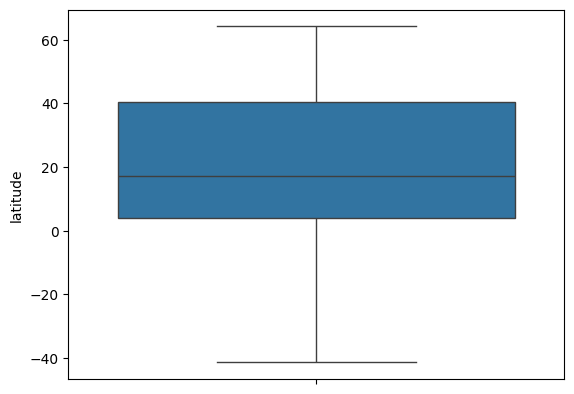

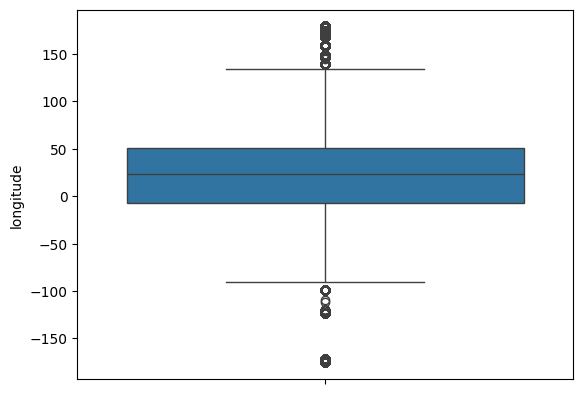

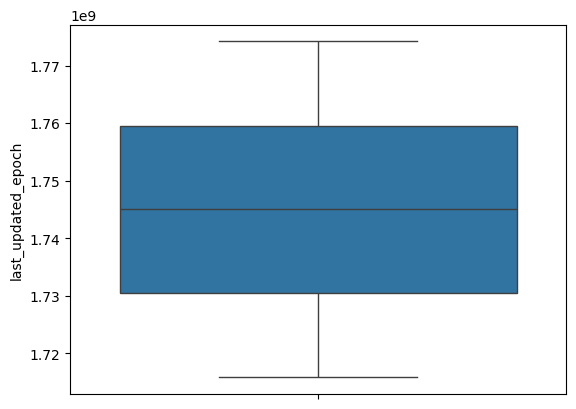

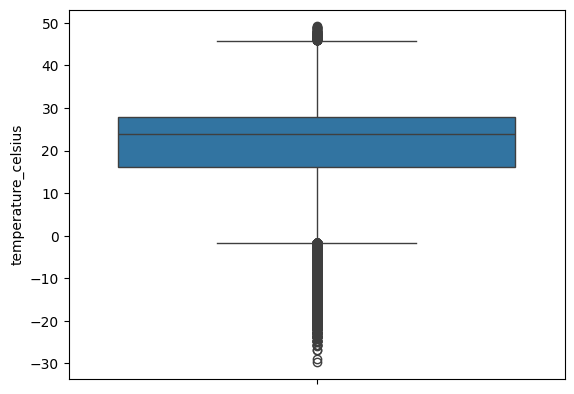

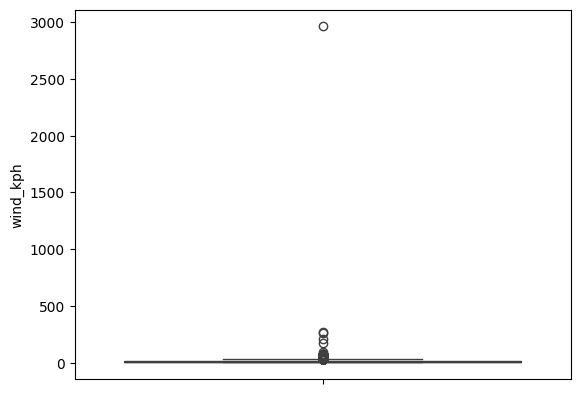

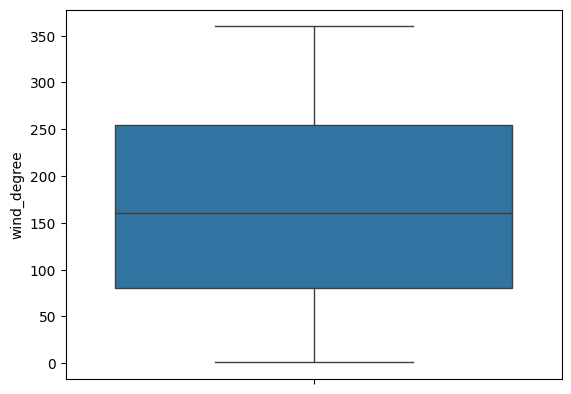

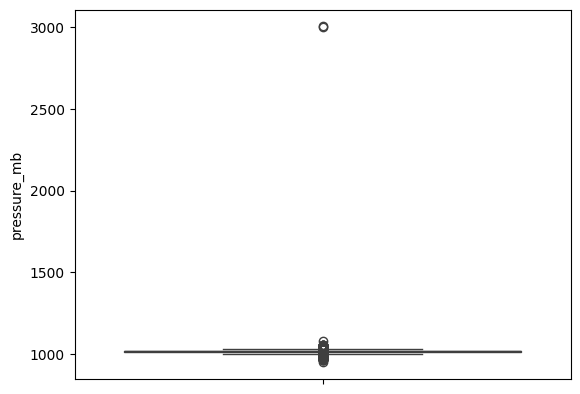

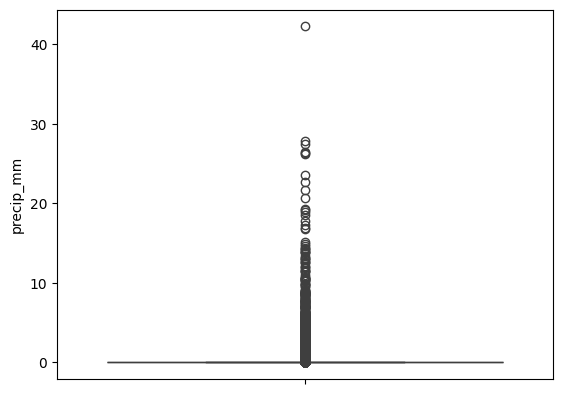

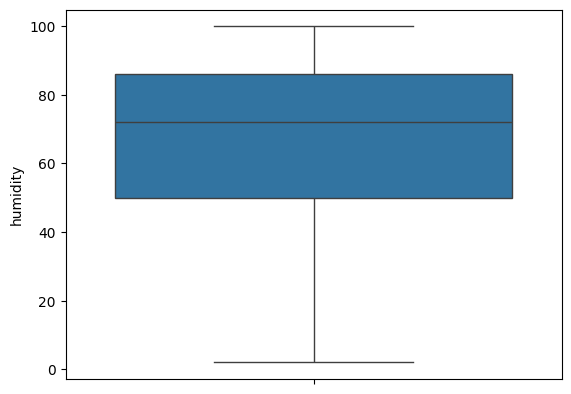

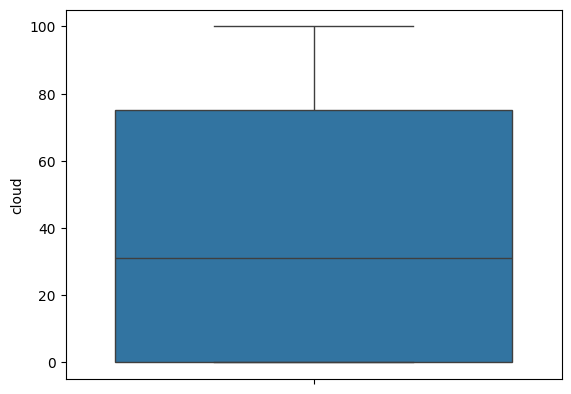

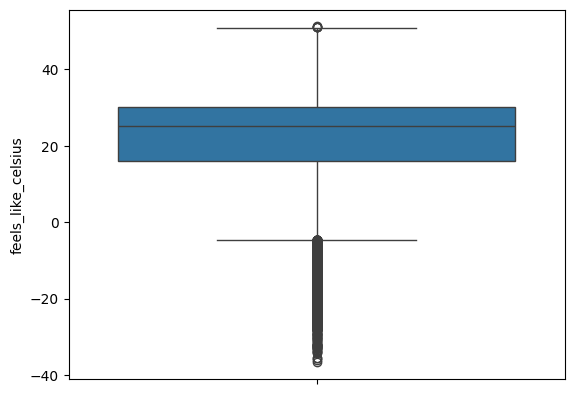

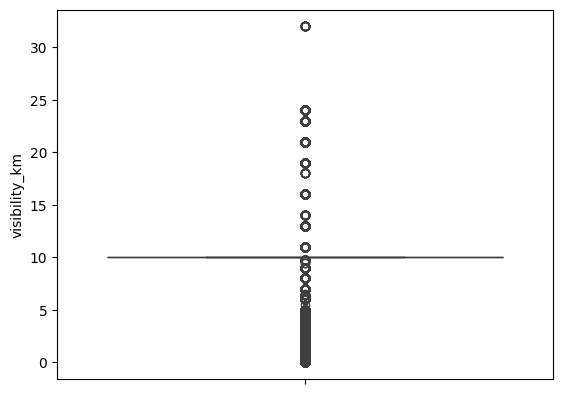

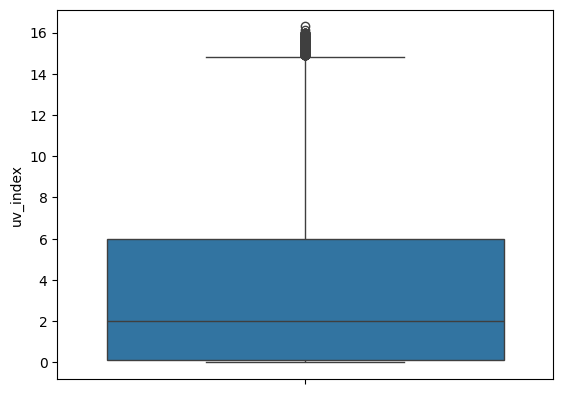

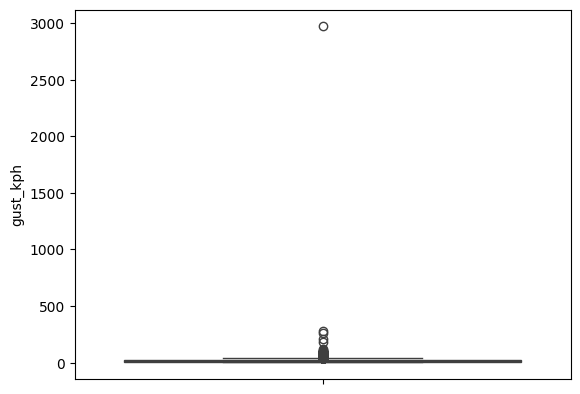

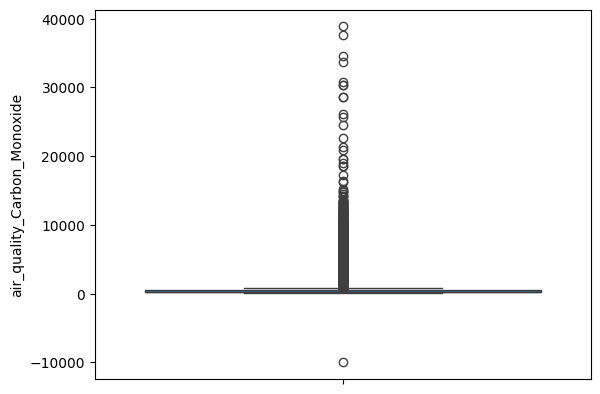

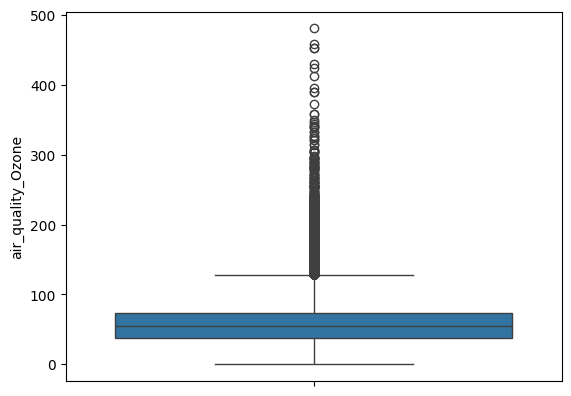

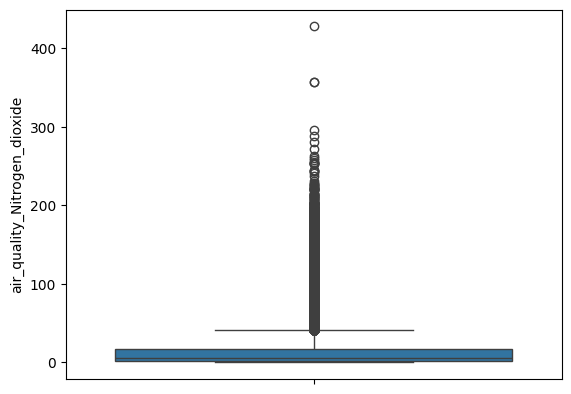

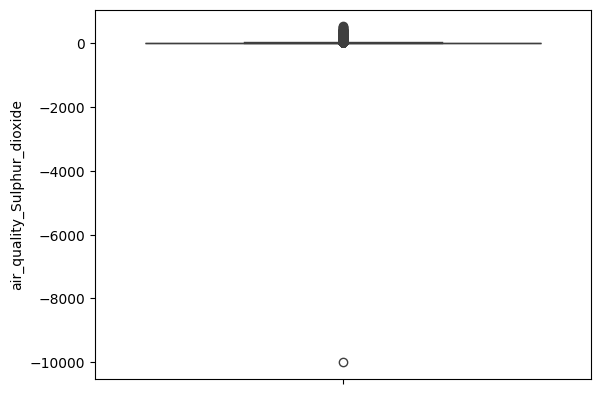

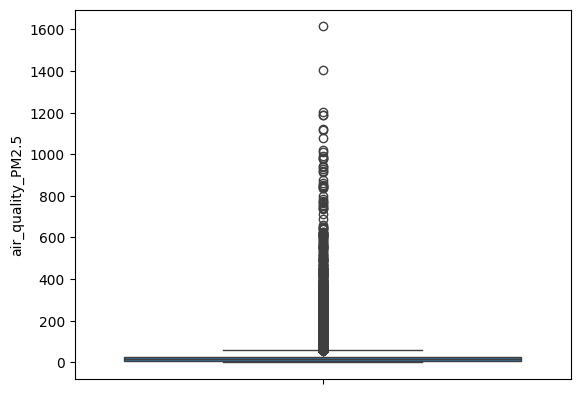

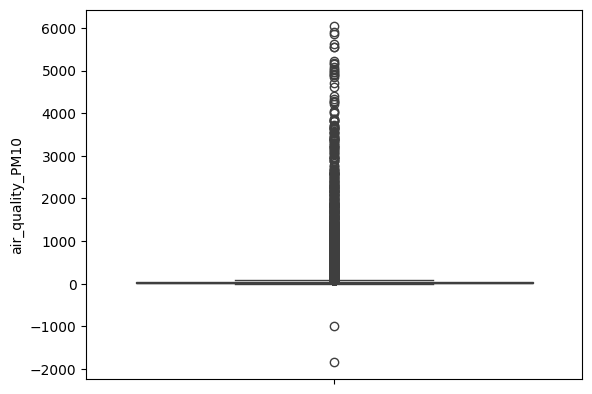

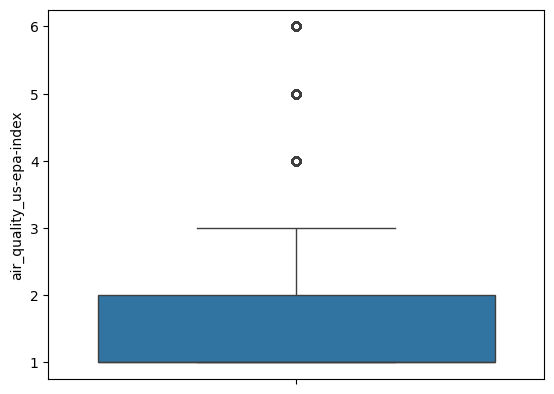

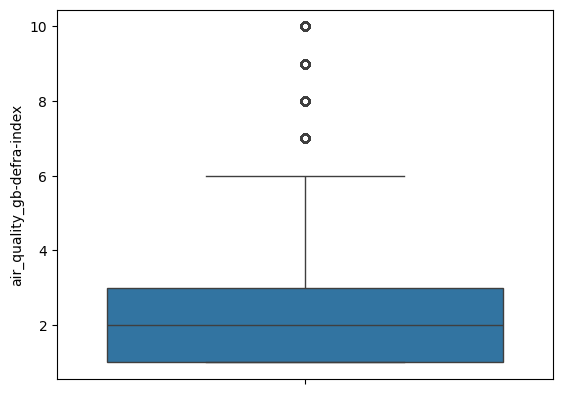

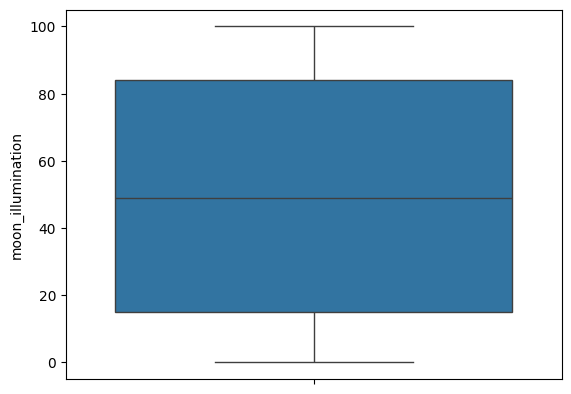

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns

for column in numeric_columns:
    sns.boxplot(y=column, data=df)
    plt.show()

Outliers found in almost all the numeric columns of the dataset. We proceed to handle the outliers by:
- having a dataset with all the outliers
- having a dataset deleting all the outliers

We are going to use them to compare results.

In [7]:
def remove(df, ls):
    ls = sorted(set(ls))
    df = df.drop(ls)
    return df


def outliers(df, ft):
    q1 = df[ft].quantile(0.25)
    q3 = df[ft].quantile(0.75)
    iqr = q3 - q1

    low = q1 - 1.5 * iqr
    up = q3 + 1.5 * iqr

    ls = df.index[(df[ft] < low) | (df[ft] > up)]

    return ls


def delete_outliers(df, list):
    n = 100
    df_clean = df
    for i in range(n):
        index_list = []
        for feature in list:
            index_list.extend(outliers(df_clean, feature))
        if not index_list:
            break
        df_clean = remove(df_clean, index_list)
    return df_clean


def replace_outliers_median(df, columns):
    df_clean = df.copy()

    for column in columns:
        median_value = df_clean[column].median()

        q1 = df_clean[column].quantile(0.25)
        q3 = df_clean[column].quantile(0.75)
        iqr = q3 - q1

        lower_limit = q1 - 1.5 * iqr
        upper_limit = q3 + 1.5 * iqr

        df_clean[column] = df_clean[column].apply(
            lambda x: median_value if x < lower_limit or x > upper_limit else x
        )

    return df_clean


df_normal = df.copy()

df_without_outliers = delete_outliers(df, numeric_columns)

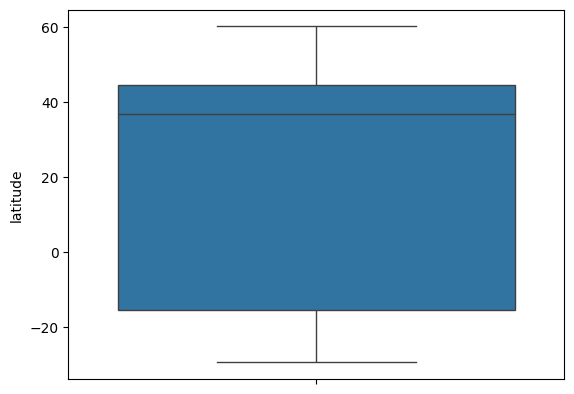

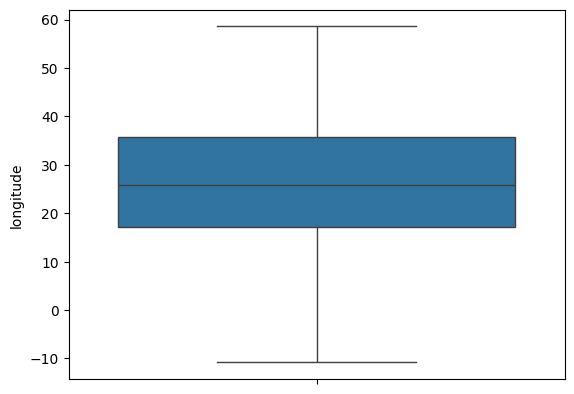

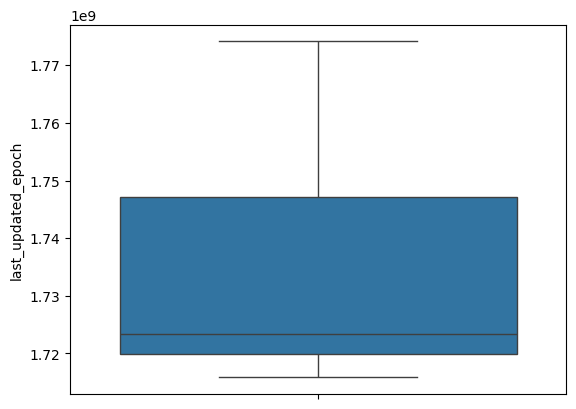

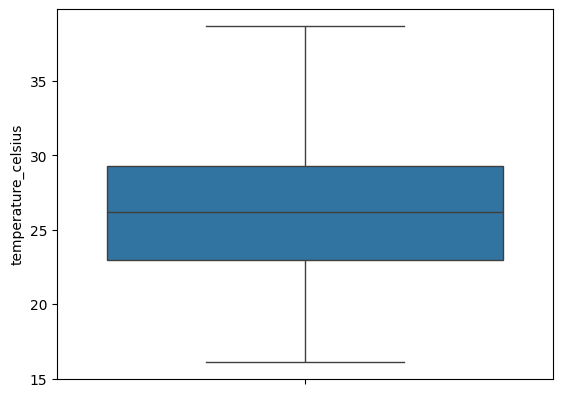

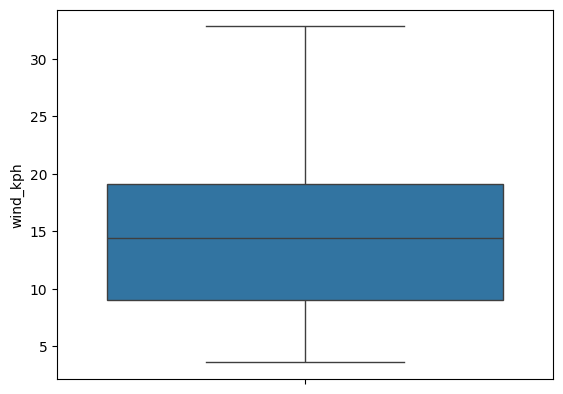

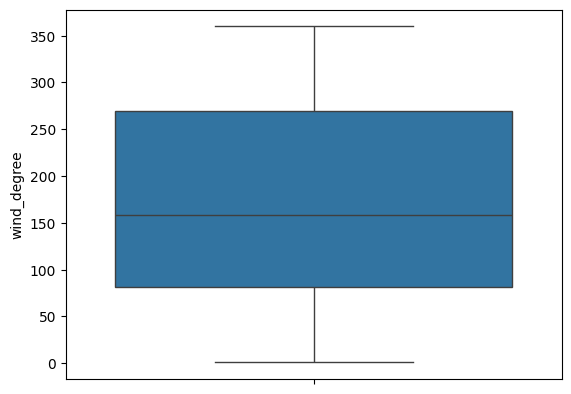

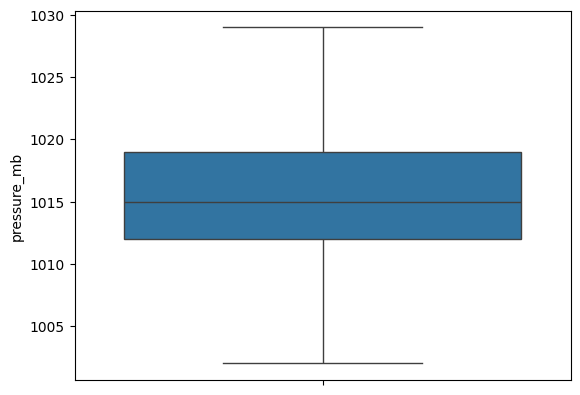

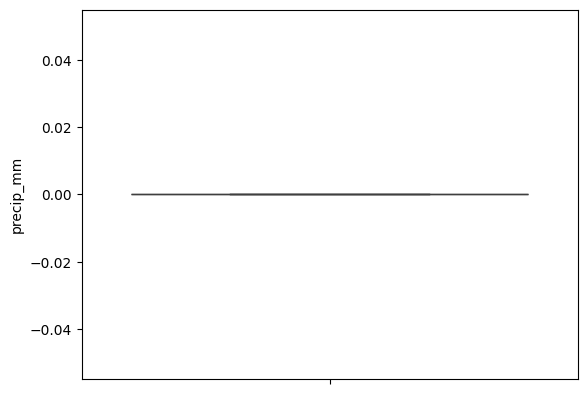

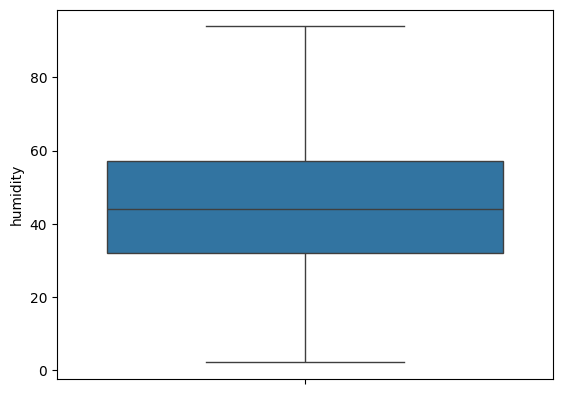

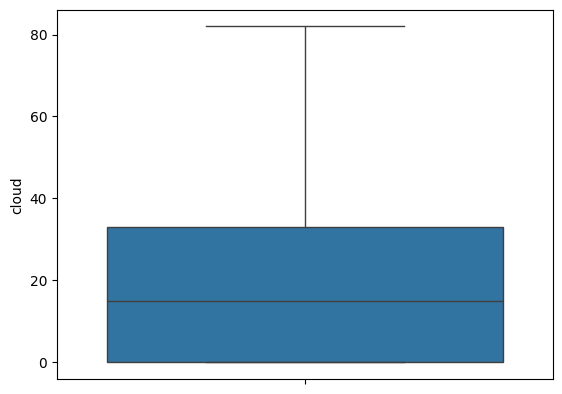

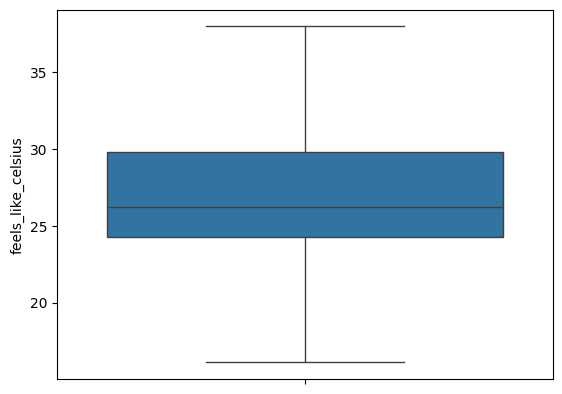

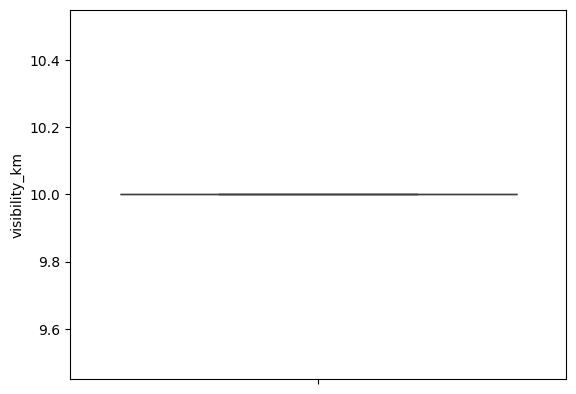

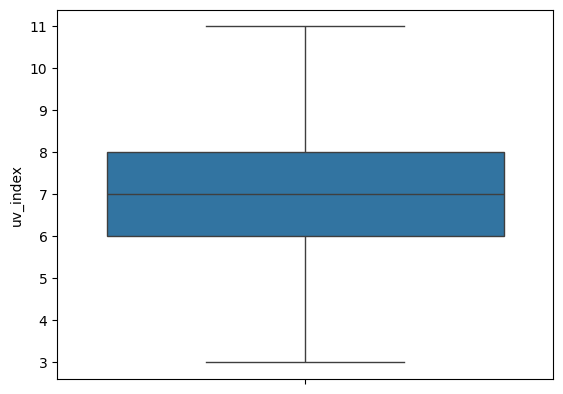

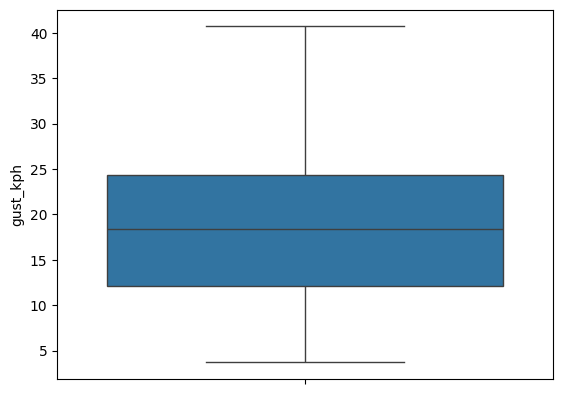

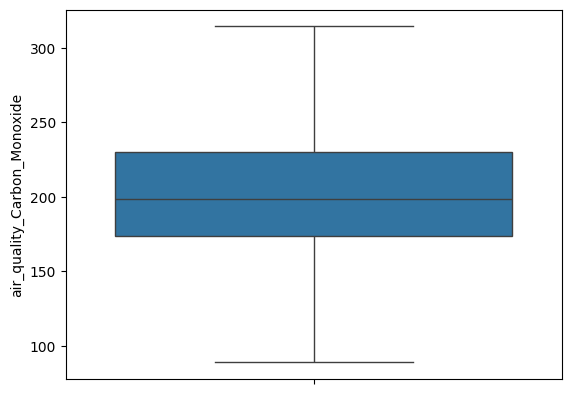

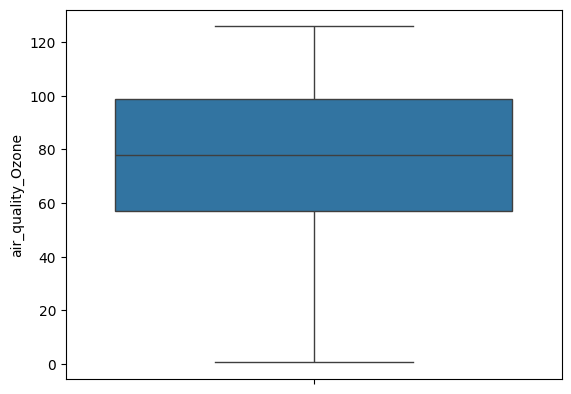

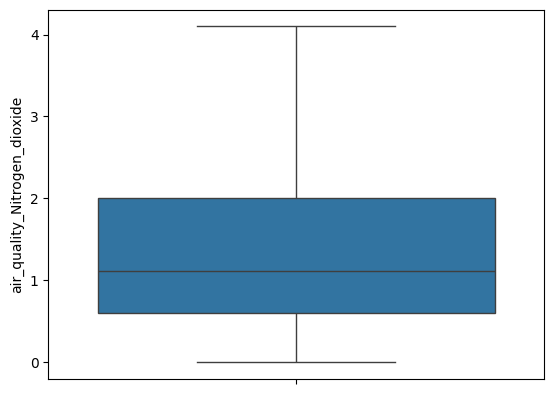

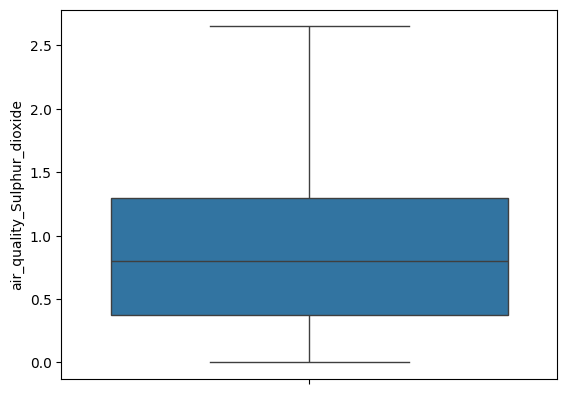

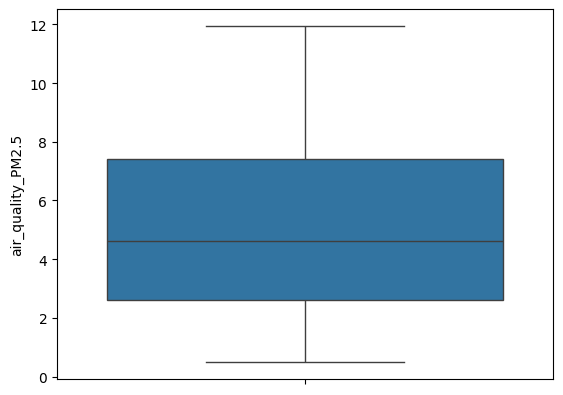

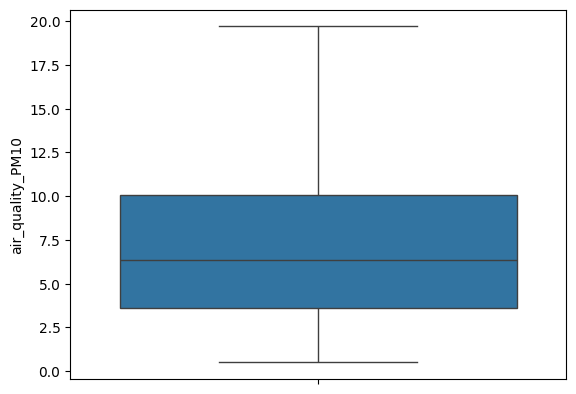

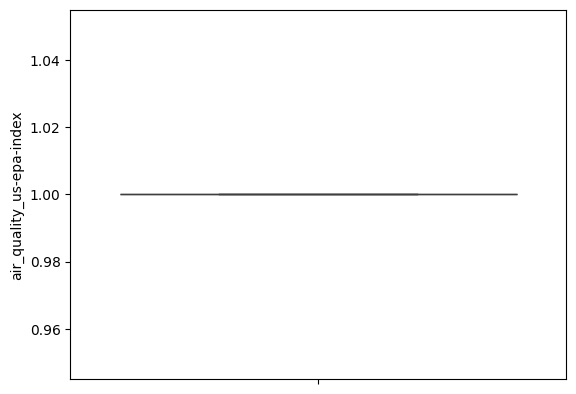

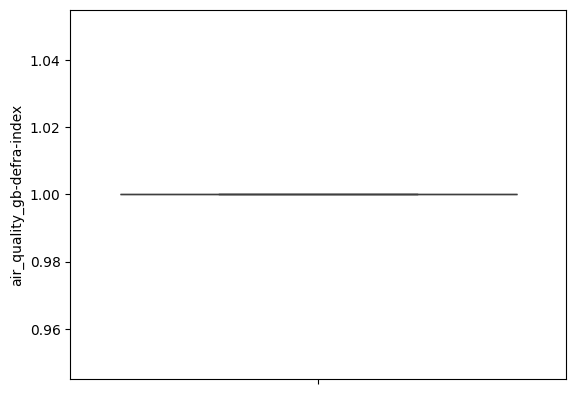

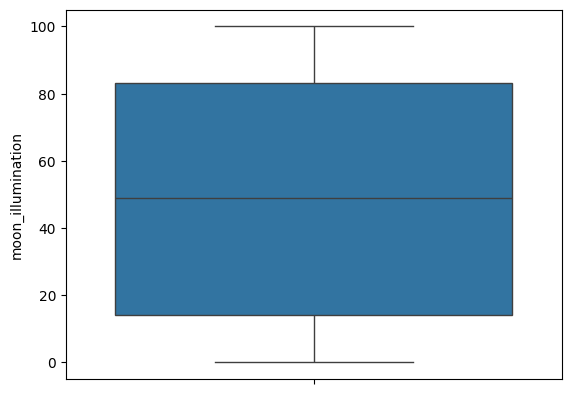

In [8]:
for column in numeric_columns:
    sns.boxplot(y=column, data=df_without_outliers)
    plt.show()

In [9]:
df_without_outliers.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4521 entries, 15 to 130975
Data columns (total 34 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   country                       4521 non-null   object 
 1   location_name                 4521 non-null   object 
 2   latitude                      4521 non-null   float64
 3   longitude                     4521 non-null   float64
 4   timezone                      4521 non-null   object 
 5   last_updated_epoch            4521 non-null   int64  
 6   last_updated                  4521 non-null   object 
 7   temperature_celsius           4521 non-null   float64
 8   condition_text                4521 non-null   object 
 9   wind_kph                      4521 non-null   float64
 10  wind_degree                   4521 non-null   int64  
 11  wind_direction                4521 non-null   object 
 12  pressure_mb                   4521 non-null   float64
 13  preci

The database without outliers has just 4521 entries. That is 3.44% of the original database. We can assume that this database does not have enough infortmation to give us good predictions.

There seems to be a large number of outliers due  of weather in the countries.

## Exploratory Data Analysis (EDA)

We proceed to do some visualizations about temeprature and precipitation

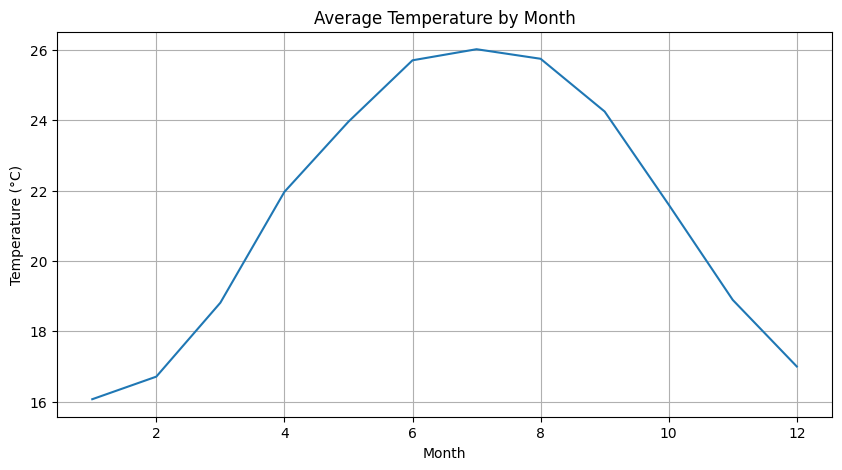

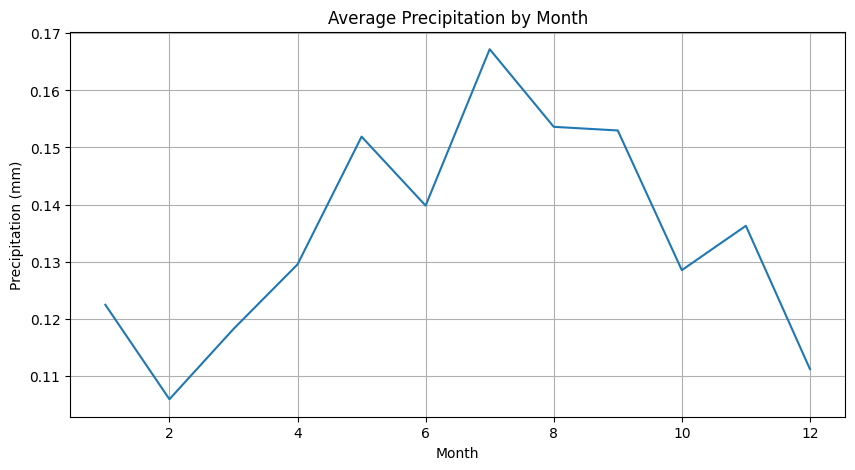

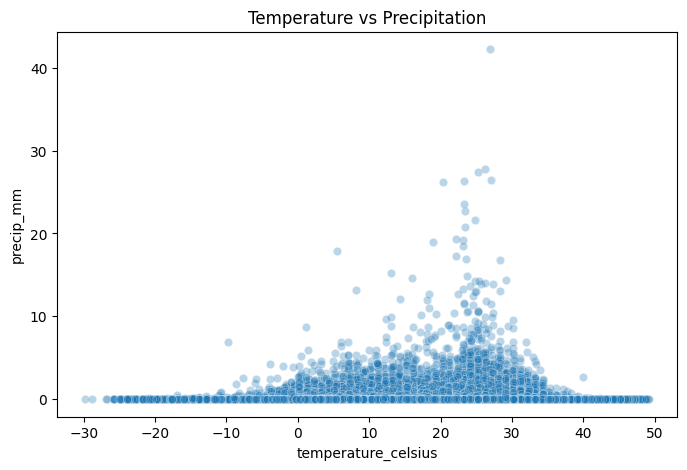

In [10]:
df["last_updated"] = pd.to_datetime(df["last_updated"])

df["year"] = df["last_updated"].dt.year
df["month"] = df["last_updated"].dt.month
df["day"] = df["last_updated"].dt.day
df["hour"] = df["last_updated"].dt.hour

plt.figure(figsize=(10,5))

df.groupby("month")["temperature_celsius"].mean().plot()

plt.title("Average Temperature by Month")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.grid()
plt.show()

plt.figure(figsize=(10,5))

df.groupby("month")["precip_mm"].mean().plot()

plt.title("Average Precipitation by Month")
plt.xlabel("Month")
plt.ylabel("Precipitation (mm)")
plt.grid()
plt.show()

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="temperature_celsius",
    y="precip_mm",
    alpha=0.3
)

plt.title("Temperature vs Precipitation")
plt.show()

The tendencies are:
- The hottest season is between May and October.
- The rainiest season is between May and October.
- The places with temperature between 20°C and 30°C have more rain than the others.

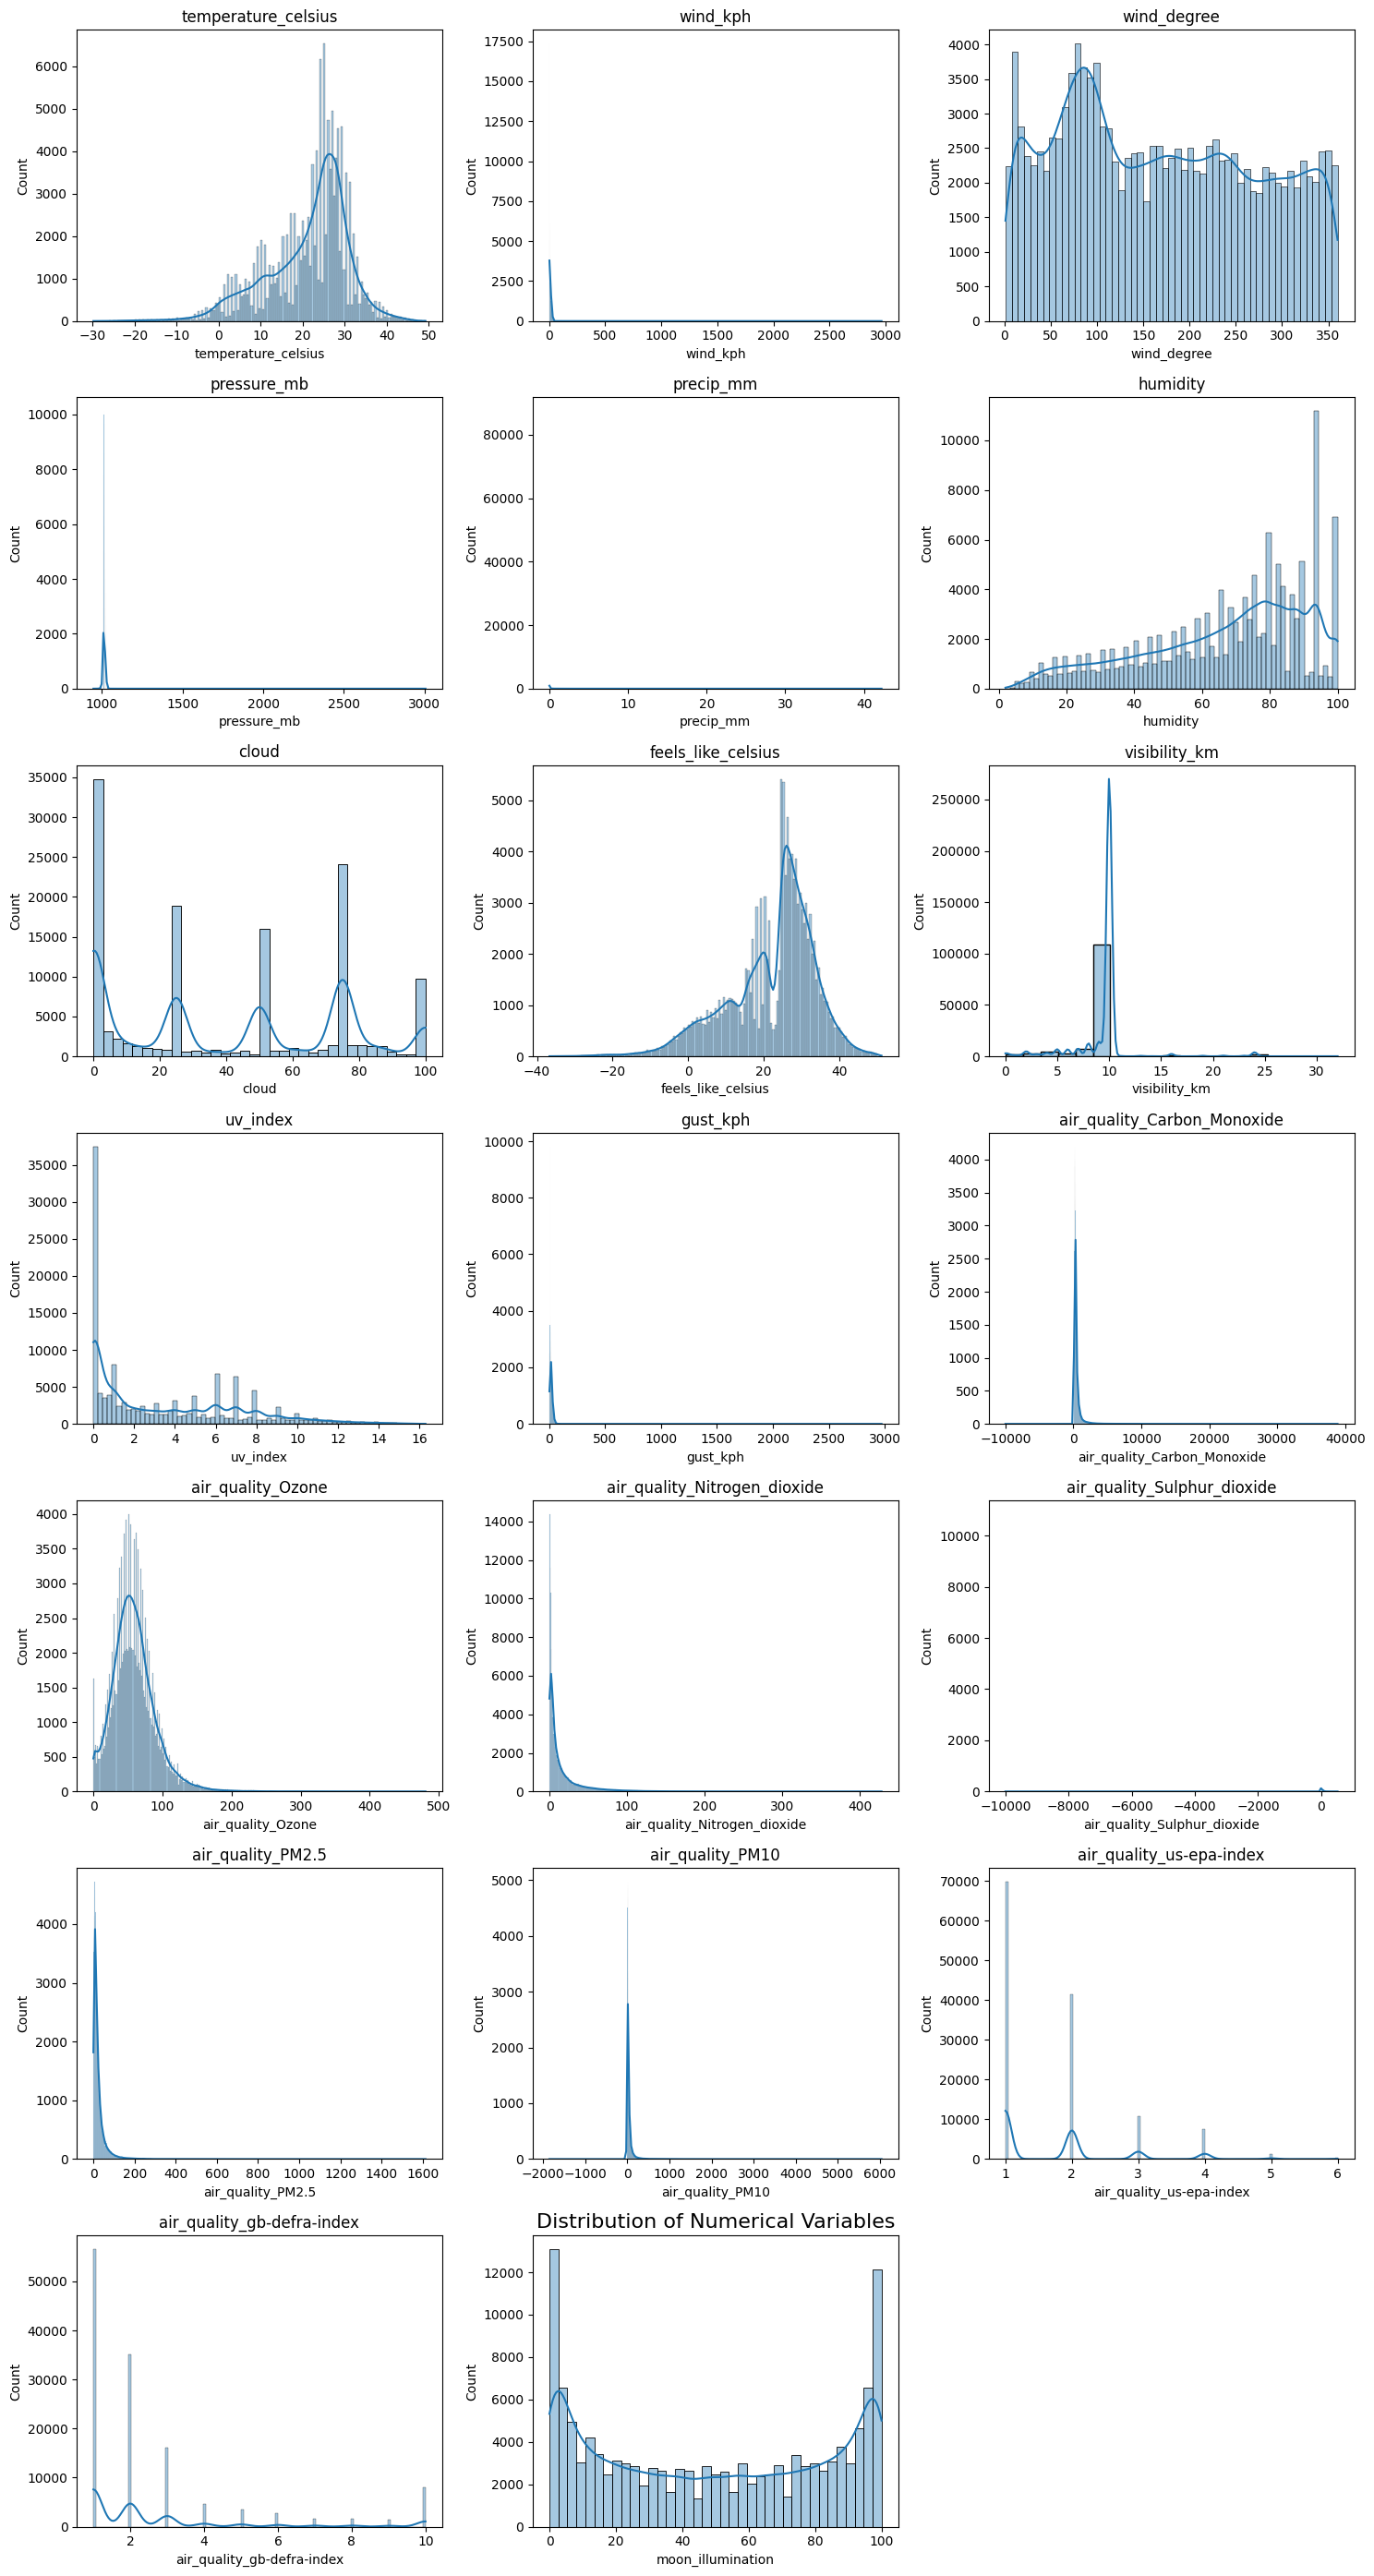

In [11]:
import math


df_EDA = df_normal.copy()

columns_to_drop = [
    "latitude",
    "longitude",
    "last_updated_epoch",
]

df_EDA = df_EDA.drop(columns=[col for col in columns_to_drop])

numeric_columns = df_EDA.select_dtypes(include=['float64', 'int64']).columns

n_cols = 3
n_rows = math.ceil(len(numeric_columns) / n_cols)

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(15, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_columns):
    sns.histplot(
        data=df_EDA,
        x=col,
        kde=True,
        ax=axes[i],
        alpha=0.4
    )
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.title("Distribution of Numerical Variables", fontsize=16)
plt.tight_layout()
plt.show()

From this distribution we can see:
- The average temperature are between 20 and 30 degrees Celsius. There are more warm places than cold ones.
- Almost all places have a low wind speed in kilometers per hour. There are few places with extremes.
- Almost all places have the standard value of pressure in millibars (1035mb).
- There are a lot of places with a high percentage of humidity.
- Most of the places have a low level of UV index. There are minimal danger from the sun's rays.
- The average ozone's level is between 50 and 70 pbb. There are a lot of places with 0 pbb, but this is imposible, they may be missing data.
- Almost all places have a good level of nitrogen dioxide.
- According to the AQI, most countries have a good or moderate level of air quality.
- According to the GB defra index, there are a low level of air pollution in the average of places.



We can see some categorical data like gb-defra-index and us-epa-index.
There are values as percentages like cloud, humidity and moon ilumination.

In [12]:
columns_to_drop = [
    "air_quality_gb-defra-index",
    "air_quality_us-epa-index",
    "humidity",
    "cloud",
    "moon_illumination",
    "wind_degree"
]

df_EDA = df_EDA.drop(columns=[col for col in columns_to_drop])

In [13]:
numeric_columns = df_EDA.select_dtypes(include=['float64', 'int64']).columns

print(f'\nThe variance is:\n{df_EDA.var(numeric_only=True)}')



The variance is:
temperature_celsius                 94.019579
wind_kph                           137.104222
pressure_mb                        109.491767
precip_mm                            0.317113
feels_like_celsius                 134.378505
visibility_km                        7.228968
uv_index                            12.643120
gust_kph                           193.011269
air_quality_Carbon_Monoxide     588591.160467
air_quality_Ozone                  956.373144
air_quality_Nitrogen_dioxide       572.372185
air_quality_Sulphur_dioxide       1308.067888
air_quality_PM2.5                 1389.416577
air_quality_PM10                 22664.985585
dtype: float64


We can see a high variance in air_quality_Carbon_Monoxide, air_quality_PM10. This is probably due to the outliers. 

We can see medium variance in gust_kph, wind_kph, feels_like_celsius, pressure_mb and temperature_celsius.

We can see low variance in precip_mm, visibility_km, uv_index. A great portion of the information has the same value.

In [14]:
import numpy as np


print(f'\nStandard Deviation per row:\n{df_EDA.std(axis=0, numeric_only=True)}')


Standard Deviation per row:
temperature_celsius               9.696369
wind_kph                         11.709151
pressure_mb                      10.463831
precip_mm                         0.563128
feels_like_celsius               11.592174
visibility_km                     2.688674
uv_index                          3.555717
gust_kph                         13.892850
air_quality_Carbon_Monoxide     767.196950
air_quality_Ozone                30.925283
air_quality_Nitrogen_dioxide     23.924301
air_quality_Sulphur_dioxide      36.167221
air_quality_PM2.5                37.274879
air_quality_PM10                150.548947
dtype: float64


We can see a low deviation in temperature_celsius, wind_kph, gust_kph, pressure_mb, precip_mm, visibility_km, uv_index. Most values are within the average range.

As in the variance air_quality_Carbon_Monoxide and air_quality_PM10 has a high deviations due the outliers.

In [15]:
for i, colum in enumerate(numeric_columns):
    print(f"\nRANGE OF {colum}")
    print(f'The range is: {df_EDA[colum].max() - df_EDA[colum].min()}')


RANGE OF temperature_celsius
The range is: 79.0

RANGE OF wind_kph
The range is: 2959.6

RANGE OF pressure_mb
The range is: 2059.0

RANGE OF precip_mm
The range is: 42.24

RANGE OF feels_like_celsius
The range is: 87.9

RANGE OF visibility_km
The range is: 32.0

RANGE OF uv_index
The range is: 16.3

RANGE OF gust_kph
The range is: 2966.8

RANGE OF air_quality_Carbon_Monoxide
The range is: 48878.398

RANGE OF air_quality_Ozone
The range is: 480.7

RANGE OF air_quality_Nitrogen_dioxide
The range is: 427.7

RANGE OF air_quality_Sulphur_dioxide
The range is: 10520.33

RANGE OF air_quality_PM2.5
The range is: 1613.932

RANGE OF air_quality_PM10
The range is: 7885.4400000000005


In the range we can see some errors on the data. The wind_kph is more than 2900 km/h, the pressure_mb is 2059 while the normal value is 870 to 1050 mb.

We proceed to filter this data:

In [16]:
df_EDA = df_EDA[df_EDA["wind_kph"] < 400]
df_EDA = df_EDA[df_EDA["gust_kph"] < 400]
df_EDA = df_EDA[(df_EDA["pressure_mb"] > 870) & (df_EDA["pressure_mb"] < 1085)]

In [17]:
for i, colum in enumerate(numeric_columns):
    print(f"\nTHE INTERQUARTILE RANGE OF {colum}")
    print(f'The IQR is: {df_EDA[colum].quantile(0.75) - df_EDA[colum].quantile(0.25)}')


THE INTERQUARTILE RANGE OF temperature_celsius
The IQR is: 11.899999999999999

THE INTERQUARTILE RANGE OF wind_kph
The IQR is: 11.500000000000002

THE INTERQUARTILE RANGE OF pressure_mb
The IQR is: 8.0

THE INTERQUARTILE RANGE OF precip_mm
The IQR is: 0.03

THE INTERQUARTILE RANGE OF feels_like_celsius
The IQR is: 13.899999999999999

THE INTERQUARTILE RANGE OF visibility_km
The IQR is: 0.0

THE INTERQUARTILE RANGE OF uv_index
The IQR is: 5.9

THE INTERQUARTILE RANGE OF gust_kph
The IQR is: 13.899999999999999

THE INTERQUARTILE RANGE OF air_quality_Carbon_Monoxide
The IQR is: 259.35

THE INTERQUARTILE RANGE OF air_quality_Ozone
The IQR is: 36.0

THE INTERQUARTILE RANGE OF air_quality_Nitrogen_dioxide
The IQR is: 15.91

THE INTERQUARTILE RANGE OF air_quality_Sulphur_dioxide
The IQR is: 7.4

THE INTERQUARTILE RANGE OF air_quality_PM2.5
The IQR is: 20.784999999999997

THE INTERQUARTILE RANGE OF air_quality_PM10
The IQR is: 31.810000000000002


In the Interquartile range we can see 2 things:
- The visibility_km is 0, so 50% of the data are the same. there are no real variation. This data is not useful.
- The precip_mm is 0.03, so it doesn't rain most days.

We proceed to quit the visibility_km of the database:

In [18]:
df_EDA = df_EDA.drop(columns=["visibility_km"])

In [19]:
cv = lambda x: np.std(x, ddof=1) / np.mean(x) * 100
print(
    f'\nThe coefficient of variation is:\n{df_EDA.select_dtypes(include=["int16", "int32", "int64", "float16", "float32", "float64"]).apply(cv)}')


The coefficient of variation is:
temperature_celsius              45.374981
wind_kph                         65.147096
pressure_mb                       0.691545
precip_mm                       417.145938
feels_like_celsius               52.135876
uv_index                        105.592635
gust_kph                         61.615192
air_quality_Carbon_Monoxide     164.202863
air_quality_Ozone                52.996666
air_quality_Nitrogen_dioxide    158.283190
air_quality_Sulphur_dioxide     344.669604
air_quality_PM2.5               152.741303
air_quality_PM10                308.387667
dtype: float64


In [20]:
print(f"\nAsymmetry measures are:\n{df_EDA.skew(numeric_only=True)}")


Asymmetry measures are:
temperature_celsius              -0.876467
wind_kph                          1.670732
pressure_mb                       0.037160
precip_mm                        17.684067
feels_like_celsius               -0.853817
uv_index                          0.882165
gust_kph                          1.492873
air_quality_Carbon_Monoxide      13.140975
air_quality_Ozone                 1.235209
air_quality_Nitrogen_dioxide      3.167186
air_quality_Sulphur_dioxide    -160.204047
air_quality_PM2.5                 8.987276
air_quality_PM10                 16.722462
dtype: float64


In [21]:
print(f"\nThe kurtosis measures are:\n{df_EDA.kurt(numeric_only=True)}")


The kurtosis measures are:
temperature_celsius                 0.861230
wind_kph                           16.912504
pressure_mb                         1.914748
precip_mm                         664.967635
feels_like_celsius                  0.772771
uv_index                           -0.175788
gust_kph                            7.086543
air_quality_Carbon_Monoxide       347.433549
air_quality_Ozone                   5.445504
air_quality_Nitrogen_dioxide       14.121599
air_quality_Sulphur_dioxide     44731.731834
air_quality_PM2.5                 175.245204
air_quality_PM10                  412.497313
dtype: float64


With all this metrics we can conclude:
- There are a lot of outliers or error of data.
- There are absurd values.
- There are a large dispersion of data.

In [22]:
cols = [
    "precip_mm",
    "air_quality_PM10",
    "air_quality_PM2.5",
    "air_quality_Carbon_Monoxide"
]

for col in cols:
    df_EDA[col] = np.log1p(df_EDA[col])

c:\Users\Usuario\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\arraylike.py:396: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [23]:
numeric_columns = df_EDA.select_dtypes(include=['float64', 'int64']).columns

df_eda_previous = df_EDA.copy()

df_EDA_without_outliers = delete_outliers(df_EDA, numeric_columns)

df_EDA_without_outliers.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22212 entries, 0 to 131172
Data columns (total 24 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   country                       22212 non-null  object 
 1   location_name                 22212 non-null  object 
 2   timezone                      22212 non-null  object 
 3   last_updated                  22212 non-null  object 
 4   temperature_celsius           22212 non-null  float64
 5   condition_text                22212 non-null  object 
 6   wind_kph                      22212 non-null  float64
 7   wind_direction                22212 non-null  object 
 8   pressure_mb                   22212 non-null  float64
 9   precip_mm                     22212 non-null  float64
 10  feels_like_celsius            22212 non-null  float64
 11  uv_index                      22212 non-null  float64
 12  gust_kph                      22212 non-null  float64
 13  air_q

After cleaning the data we have 22212 entries, 17% of the original dataset.

We proceed to show a correlation matrix:

In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_EDA_without_outliers[numeric_columns] = scaler.fit_transform(df_EDA_without_outliers[numeric_columns])

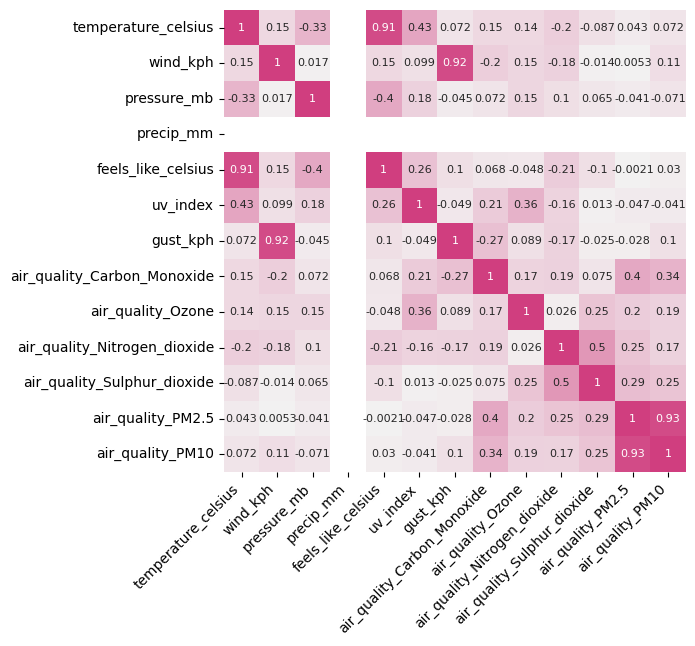

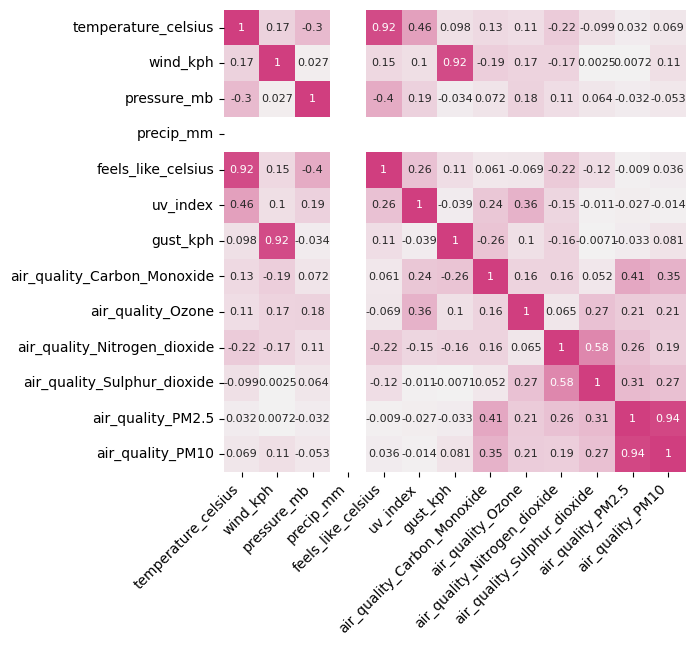

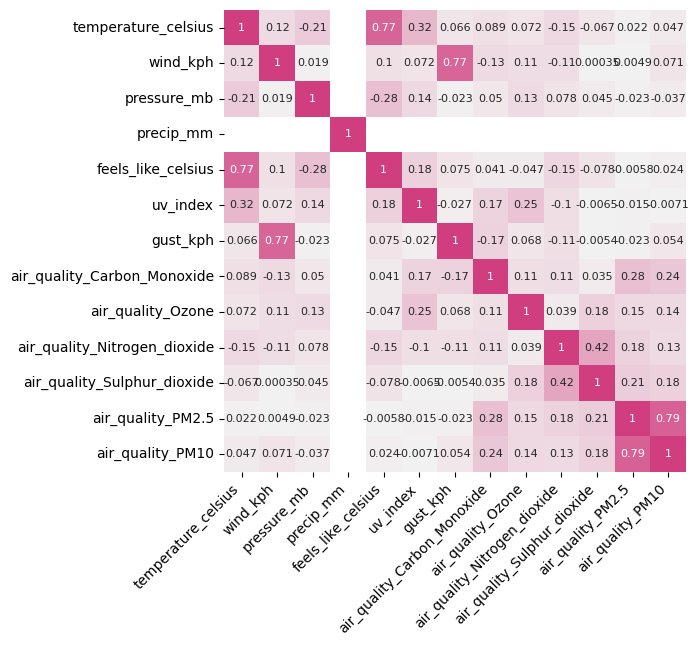

In [25]:
for i, colum in enumerate(['pearson', 'spearman', 'kendall']):
    df_corr = df_EDA_without_outliers.corr(method=colum, numeric_only=True)

    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 6))
    sns.heatmap(
        df_corr,
        annot=True,
        cbar=False,
        annot_kws={"size": 8},
        vmin=-1,
        vmax=1,
        center=0,
        cmap=sns.diverging_palette(350, 350, n=200),
        square=True,
        ax=ax
    )
    ax.set_xticklabels(
        ax.get_xticklabels(),
        rotation=45,
        horizontalalignment='right'
    )
    ax.tick_params(labelsize=10)
    plt.show()

We proceed to delete redundant data

In [26]:
drop_cols = [
    "feels_like_celsius",
    "gust_kph"
]

df_EDA_without_outliers = df_EDA_without_outliers.drop(columns=drop_cols)

## Model Building

- Prepare temporal data
- Create time features
- Create LAGS
- Drop Nans
- Define X and Y
- Temporal split
- Implement Random Forest
- Evaluate the model
- Show real data vs predicted

In [ ]:
df_EDA_without_outliers["last_updated"] = pd.to_datetime(df_EDA_without_outliers["last_updated"])
df_EDA_without_outliers = df_EDA_without_outliers.sort_values("last_updated")

In [33]:
df_EDA_without_outliers["hour"] = df_EDA_without_outliers["last_updated"].dt.hour
df_EDA_without_outliers["day"] = df_EDA_without_outliers["last_updated"].dt.day
df_EDA_without_outliers["month"] = df_EDA_without_outliers["last_updated"].dt.month
df_EDA_without_outliers["dayofweek"] = df_EDA_without_outliers["last_updated"].dt.dayofweek

df_EDA_without_outliers["lag1"] = df_EDA_without_outliers["temperature_celsius"].shift(1)
df_EDA_without_outliers["lag2"] = df_EDA_without_outliers["temperature_celsius"].shift(2)
df_EDA_without_outliers["lag3"] = df_EDA_without_outliers["temperature_celsius"].shift(3)

df_EDA_without_outliers["rolling_mean_3"] = df_EDA_without_outliers["temperature_celsius"].rolling(window=3).mean()

df_EDA_without_outliers = df_EDA_without_outliers.dropna()

Cross-validation scores: [0.98385735 0.98646673 0.99142213 0.98678765 0.98923265]
Average cross-validation score: 0.9875533015576894
Score on test data: 0.9887450547367103
DIFFERENCE:  0.0011917531790208713


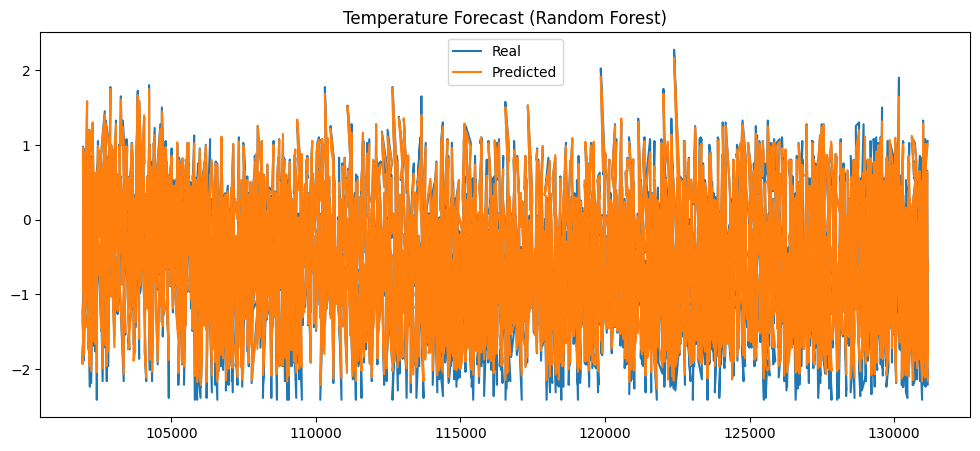

In [36]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

features = [
    "hour", "day", "month", "dayofweek",
    "lag1", "lag2", "lag3",
    "rolling_mean_3"
]

X = df_EDA_without_outliers[features]
y = df_EDA_without_outliers["temperature_celsius"]

split = int(len(df_EDA_without_outliers) * 0.8)

X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]


model = RandomForestRegressor(
    n_estimators=300,
    random_state=0
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

cv_scores = cross_val_score(model, X_train, y_train, cv=5)
mean_cv_score = cv_scores.mean()
print("Cross-validation scores:", cv_scores)
print("Average cross-validation score:", mean_cv_score)
test_score = model.score(X_test, y_test)
print("Score on test data:", test_score)

print("DIFFERENCE: ", test_score - mean_cv_score)

plt.figure(figsize=(12,5))

plt.plot(y_test.index, y_test, label="Real")
plt.plot(y_test.index, y_pred, label="Predicted")

plt.legend()
plt.title("Temperature Forecast (Random Forest)")
plt.show()

The Random Forest model showed very high performance, with values ​​close to 0.99 in both cross-validation and the test set, indicating excellent generalizability and no overfitting. 

This suggests that the generated variables, especially the time lags, effectively capture temperature dynamics. However, it should be considered that the high temporal correlation may facilitate prediction over short time horizons.